In [1]:
# ================================
#   LIBRERÍAS PARA EL ANÁLISIS
# ================================

# Sistema y utilidades
import sys
import os
sys.path.insert(0, '..')

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estadística
from scipy import stats

# Modelado y métricas
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statsmodels para diagnósticos
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Conexión a base de datos (Supabase en tu caso)
from scripts.database import engine

# Configuración estética de gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")


2026-04-16 05:46:04.336 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas      2.2.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.0


In [2]:
# ================================
#   CARGA DE DATOS
# ================================
QUERY = """
SELECT
    title,
    score,
    rank,
    favorites,
    episodes,
    type,
    year
FROM anime
WHERE score IS NOT NULL
  AND rank IS NOT NULL
  AND favorites IS NOT NULL
  AND episodes IS NOT NULL
ORDER BY rank
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados desde Supabase")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()


✅ Datos cargados desde Supabase
Filas: 485, Columnas: 7


,title,score,rank,favorites,episodes,type,year
0,Sousou no Frieren,9.28,1,85781,28,TV,2023.0
1,Sousou no Frieren 2nd Season,9.16,2,5418,10,TV,2026.0
2,Fullmetal Alchemist: Brotherhood,9.11,3,240854,64,TV,2009.0
3,Chainsaw Man Movie: Reze-hen,9.09,4,12022,1,Movie,NaN
4,Steins;Gate,9.07,5,201123,24,TV,2011.0


In [3]:
# ================================
#   INSPECCIÓN INICIAL
# ================================
print("="*50)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
print(df.info())
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())
print("\n🎬 Tipos de anime en el dataset:")
print(df['type'].value_counts())


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      485 non-null    object 
 1   score      485 non-null    float64
 2   rank       485 non-null    int64  
 3   favorites  485 non-null    int64  
 4   episodes   485 non-null    int64  
 5   type       485 non-null    object 
 6   year       294 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 26.7+ KB
None

📊 Valores nulos por columna:
title          0
score          0
rank           0
favorites      0
episodes       0
type           0
year         191
dtype: int64

🎬 Tipos de anime en el dataset:
type
TV            294
Movie         114
ONA            40
OVA            17
TV Special     11
Special         9
Name: count, dtype: int64


In [4]:
# ================================
#   ESTADISTICAS DESCRIPTIVAS
# ================================
vars_num = ['score','rank','favorites','episodes']
desc = df[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)


📊 ESTADÍSTICAS DESCRIPTIVAS
        score    rank  favorites  episodes
count  485.00  485.00     485.00    485.00
mean     8.43  246.53   13678.02     18.59
std      0.22  142.30   27878.96     35.62
min      8.16    1.00      24.00      1.00
25%      8.25  123.00     954.00      1.00
50%      8.37  247.00    3681.00     12.00
75%      8.57  369.00   13833.00     24.00
max      9.28  494.00  240854.00    500.00


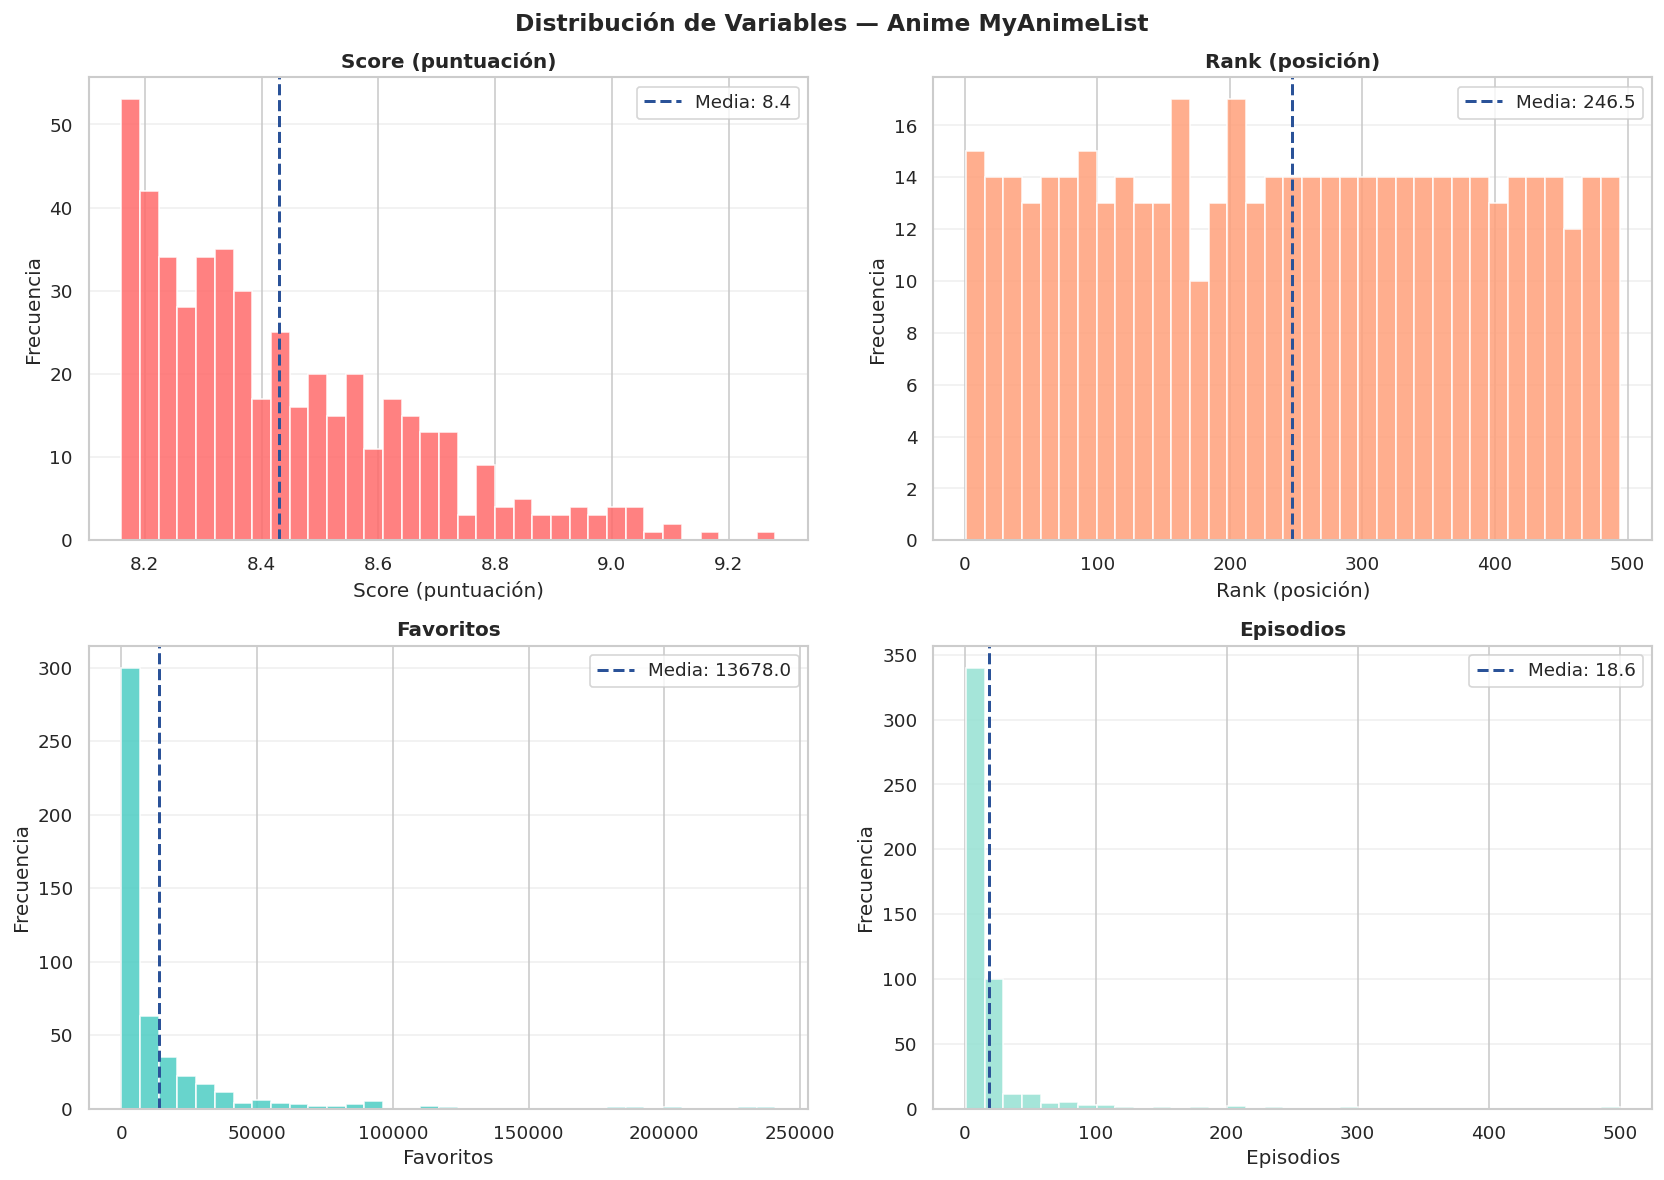

In [5]:
# ================================
#   DISTRIBUCION VARIABLES
# ================================
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Distribución de Variables — Anime MyAnimeList', fontsize=14, fontweight='bold')

datos = {
    'score'    : ('Score (puntuación)', '#ff6b6b'),
    'rank'     : ('Rank (posición)',    '#ffa07a'),
    'favorites': ('Favoritos',          '#4ecdc4'),
    'episodes' : ('Episodios',          '#95e1d3'),
}

for ax, (col,(label,color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8, label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png', dpi=300, bbox_inches='tight')
plt.show()


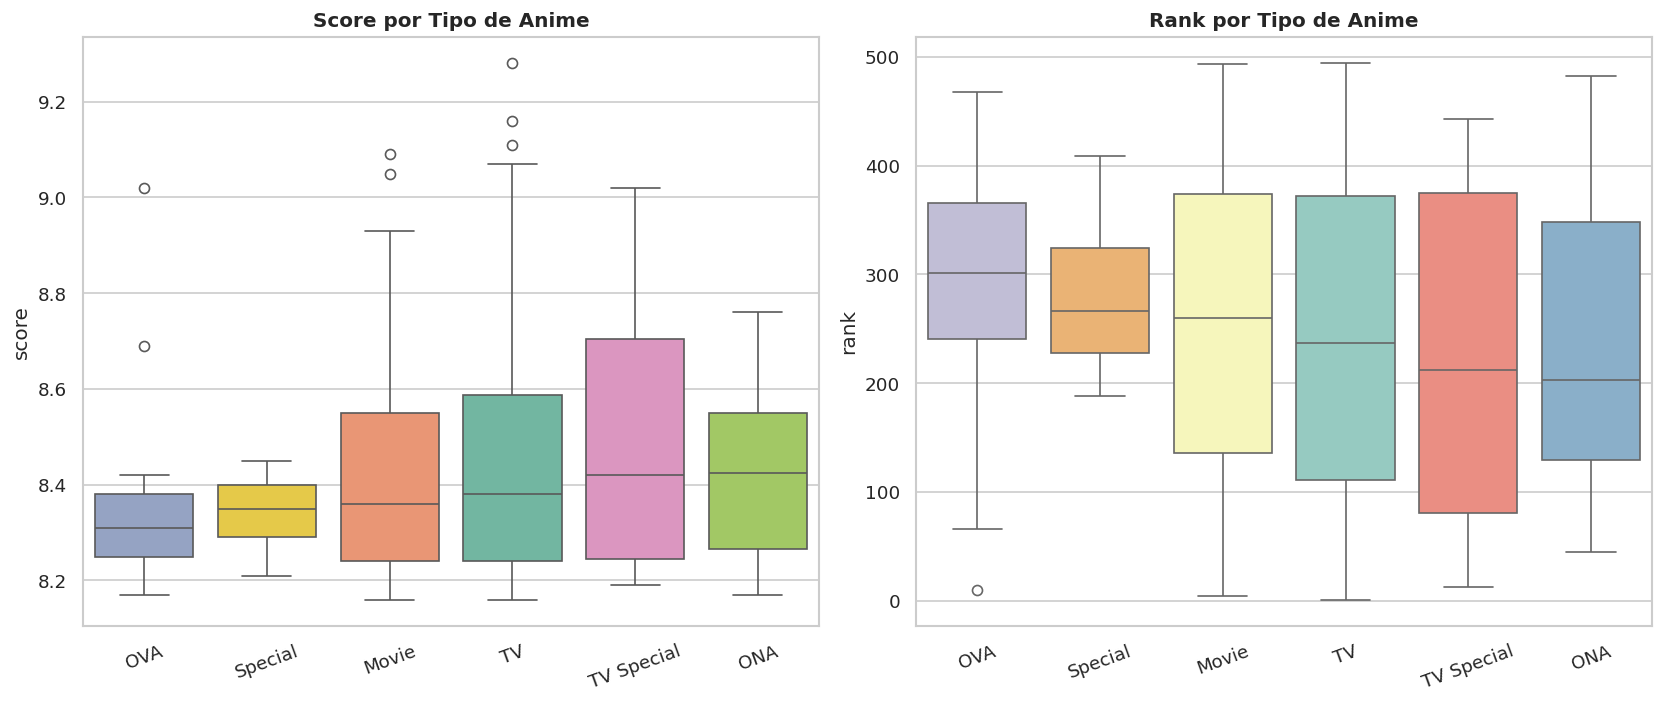

In [6]:
# ================================
#   BOXPLOTS
# ================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df.groupby('type')['score'].median().sort_values().index

# Score por tipo
sns.boxplot(data=df, x='type', y='score', order=orden,
            hue='type', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Score por Tipo de Anime', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Rank por tipo
sns.boxplot(data=df, x='type', y='rank', order=orden,
            hue='type', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Rank por Tipo de Anime', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


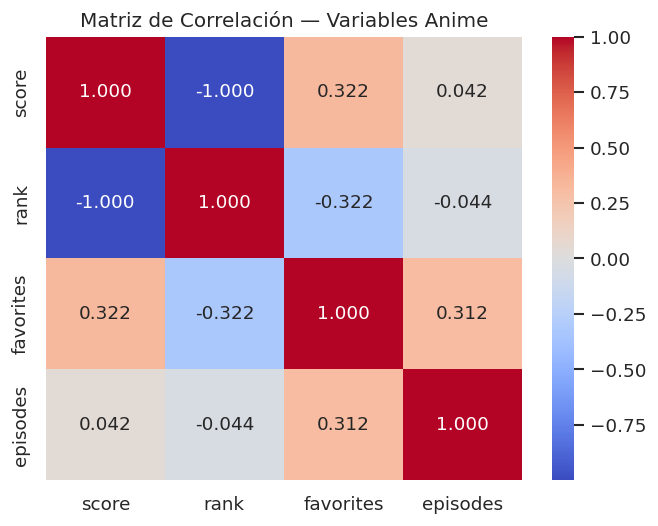


📊 Correlación con score (ordenada):
favorites    0.3223
episodes     0.0416
rank        -0.9998
Name: score, dtype: float64


In [7]:
# ================================
#   MATRIZ CORRELACION
# ================================
corr = df[vars_num].corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación — Variables Anime')
plt.savefig('../data/graficas/eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con score (ordenada):")
print(corr['score'].drop('score').sort_values(ascending=False).round(4))


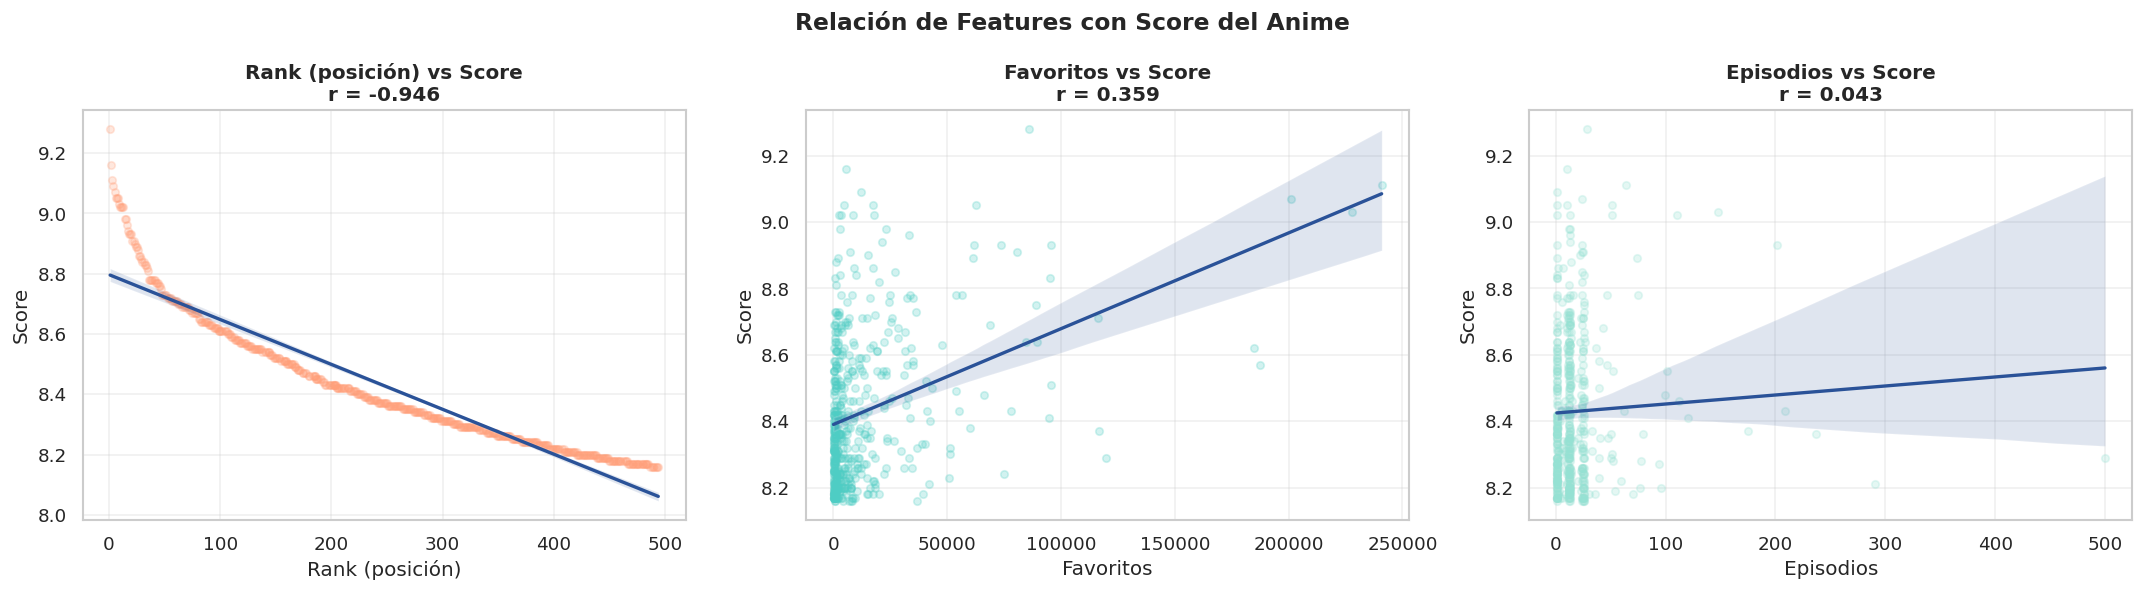

In [8]:
# ================================
#   SCATTER PLOT  SCORE VS RANK
# ================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Score del Anime', fontsize=14, fontweight='bold')

pares = [
    ('rank',      'Rank (posición)',    '#ffa07a'),
    ('favorites', 'Favoritos',          '#4ecdc4'),
    ('episodes',  'Episodios',          '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    # Scatter + línea de regresión con seaborn
    sns.regplot(
        data=df, x=feature, y='score',
        scatter_kws={'alpha':0.25, 's':20, 'color':color},
        line_kws={'color':'#2a5298','linewidth':2},
        ax=ax
    )
    
    # Calcular correlación
    r = df[[feature, 'score']].corr().iloc[0, 1]
    
    # Personalizar
    ax.set_title(f'{xlabel} vs Score\nr = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Score')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Intercepto β₀: 8.7955
Coeficiente β₁ (rank): -0.001496
R²: 0.8829
RMSE: 0.0834
MAE: 0.0555


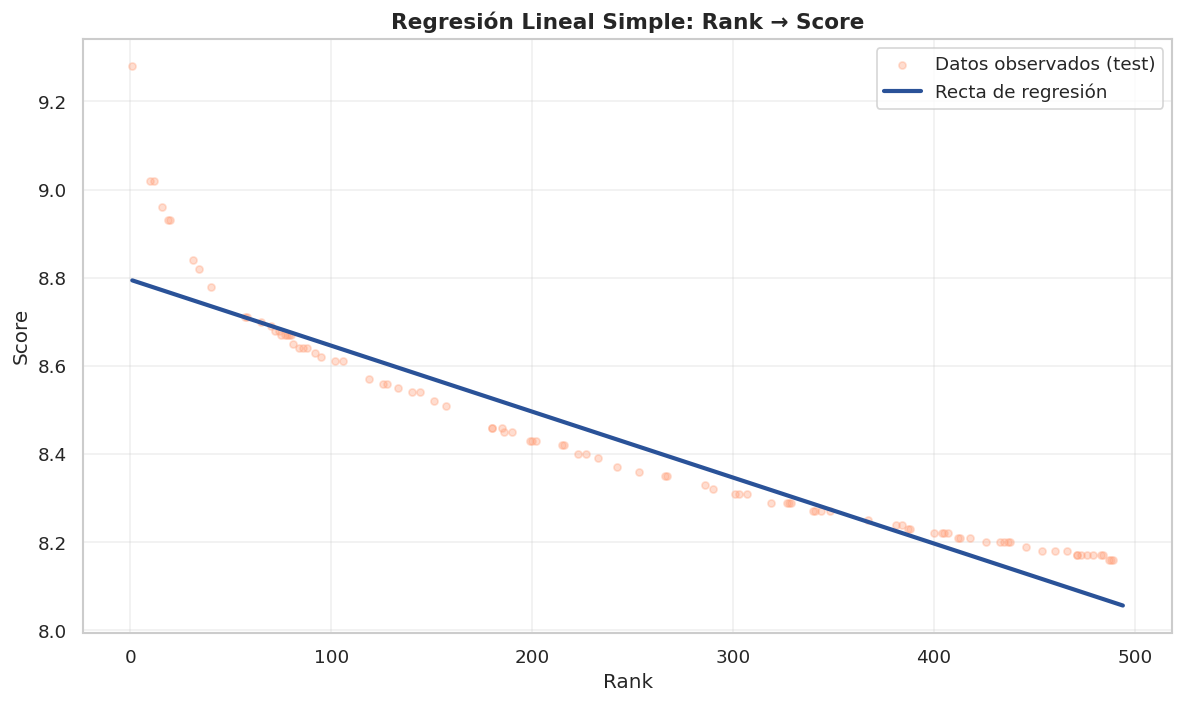

In [9]:
# ================================
#   GRÁFICA: REGRESIÓN SIMPLE (Score ~ Rank)
# ================================

# Variables
X_simple = df[['rank']].values
y = df['score'].values

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Modelo
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)
y_pred_simple = modelo_simple.predict(X_test)

# Métricas
print(f"Intercepto β₀: {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ (rank): {modelo_simple.coef_[0]:.6f}")
print(f"R²: {r2_score(y_test, y_pred_simple):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_simple, squared=False):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_simple):.4f}")

# ================================
#   GRÁFICA DE LA RECTA
# ================================
fig, ax = plt.subplots(figsize=(10, 6))

# Puntos observados (test)
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#ffa07a', label='Datos observados (test)')

# Recta de regresión
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#2a5298', linewidth=2.5, label='Recta de regresión')

# Personalización
ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Regresión Lineal Simple: Rank → Score',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Guardar imagen
plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png', dpi=300, bbox_inches='tight')
plt.show()

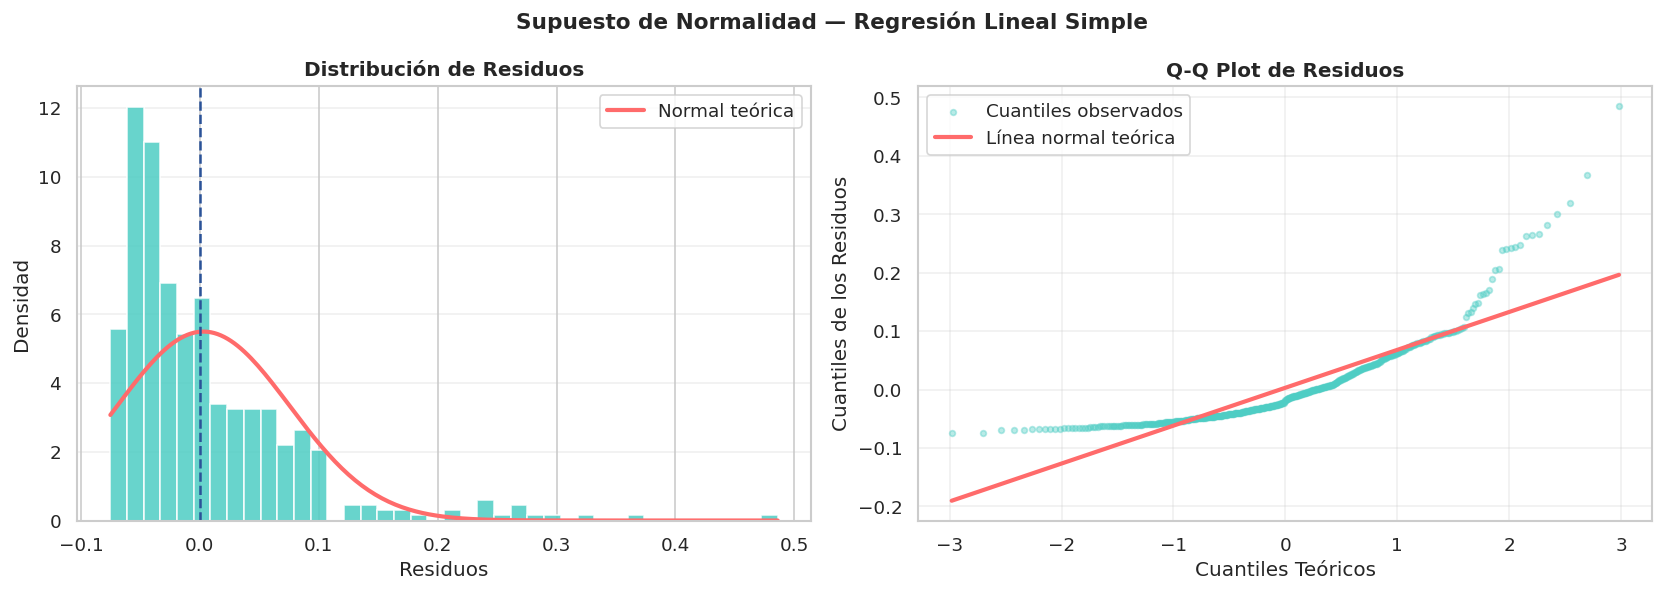


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.7933
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n grande el test es muy sensible — revisar Q-Q plot


In [10]:
# Residuos del modelo simple
y_pred_all = modelo_simple.predict(df[['rank']].values)
residuos   = df['score'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n grande el test es muy sensible — revisar Q-Q plot")

In [11]:
# ================================
#   REGRESION MULTIPLE
# ================================
FEATURES = ['rank','favorites','episodes']
X_multi = df[FEATURES].values
y = df['score'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)
y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto β₀: {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat}: {coef:.6f}")

print(f"R²: {r2_score(y_test_m, y_pred_multi):.4f}")
print(f"RMSE: {mean_squared_error(y_test_m, y_pred_multi, squared=False):.4f}")
print(f"MAE: {mean_absolute_error(y_test_m, y_pred_multi):.4f}")


Intercepto β₀: 8.7783
Coeficiente rank: -0.001456
Coeficiente favorites: 0.000001
Coeficiente episodes: -0.000087
R²: 0.8902
RMSE: 0.0807
MAE: 0.0542


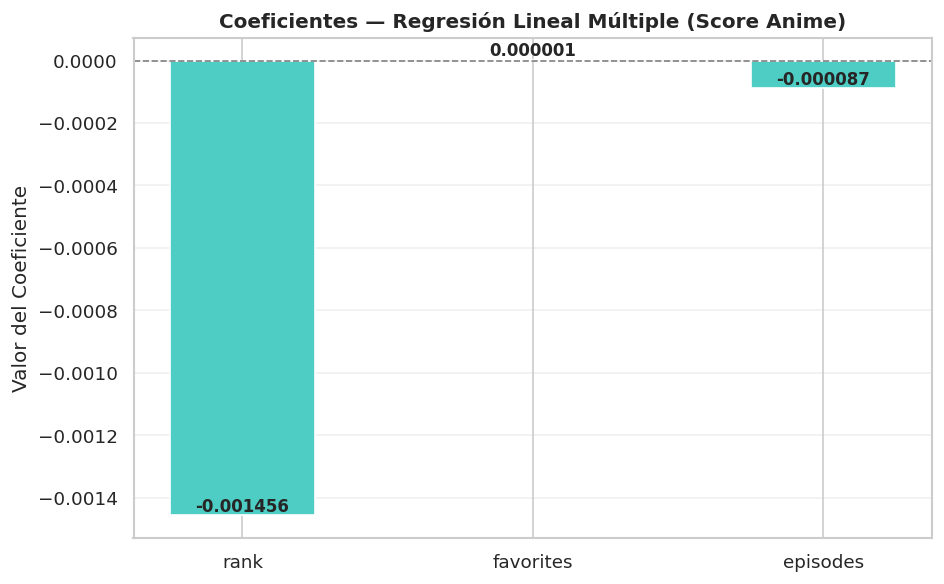

In [12]:
# ================================
#   COEFICIENTES REGRESIÓN MÚLTIPLE
# ================================

FEATURES = ['rank','favorites','episodes']
coeficientes = modelo_multi.coef_

# Colores: rojo si coeficiente positivo, verde/azul si negativo
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in coeficientes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, coeficientes,
              color=colores, edgecolor='white', width=0.5)

# Línea en cero
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# Título y etiquetas
ax.set_title('Coeficientes — Regresión Lineal Múltiple (Score Anime)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

# Mostrar valores encima de cada barra
for bar, coef in zip(bars, coeficientes):
    offset = 0.000002 if coef >= 0 else -0.000002
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{coef:.6f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3)

# Guardar imagen
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# ================================
#   DIAGNOSTICOS VIF
# ================================

# Variables del modelo múltiple
X_vif = df[['rank','favorites','episodes']].copy()

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data["VIF"] = vif_data["VIF"].round(3)

# Criterios interpretativos
def criterio(v):
    if v < 5:
        return "✅ Sin multicolinealidad (VIF < 5)"
    elif v < 10:
        return "⚠️ Moderada (5 ≤ VIF < 10)"
    else:
        return "❌ Severa (VIF ≥ 10)"

vif_data["Criterio"] = vif_data["VIF"].apply(criterio)

# Mostrar resultados
print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("="*65)
print(vif_data.to_string(index=False))
print("="*65)



📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
 Variable   VIF                          Criterio
     rank 1.192 ✅ Sin multicolinealidad (VIF < 5)
favorites 1.232 ✅ Sin multicolinealidad (VIF < 5)
 episodes 1.363 ✅ Sin multicolinealidad (VIF < 5)


In [14]:
# ================================
#   DIAGNOSTICOS OLS, BREUSH Y VIF
# ================================

# OLS simple
X_ols = sm.add_constant(df['rank'])
modelo_ols_simple = sm.OLS(df['score'], X_ols).fit()
print(modelo_ols_simple.summary())

# Breusch-Pagan simple
bp_simple = het_breuschpagan(modelo_ols_simple.resid, modelo_ols_simple.model.exog)
print("Breusch-Pagan simple:", bp_simple)

# OLS múltiple
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['score'], X_ols_m).fit()
print(modelo_ols_multi.summary())

# Breusch-Pagan múltiple
bp_multi = het_breuschpagan(modelo_ols_multi.resid, modelo_ols_multi.model.exog)
print("Breusch-Pagan múltiple:", bp_multi)

# VIF
vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [variance_inflation_factor(df[FEATURES].values, i) for i in range(len(FEATURES))]
})
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     4113.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.96e-238
Time:                        05:46:15   Log-Likelihood:                 584.31
No. Observations:                 485   AIC:                            -1165.
Df Residuals:                     483   BIC:                            -1156.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7968      0.007   1331.403      0.0

In [15]:
# ================================
#   COMPARACION FINAL
# ================================
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple','Regresión Múltiple'],
    'Variables': ['rank','rank + favorites + episodes'],
    'R²': [r2_score(y_test, y_pred_simple), r2_score(y_test_m, y_pred_multi)],
    'RMSE': [mean_squared_error(y_test, y_pred_simple, squared=False),
             mean_squared_error(y_test_m, y_pred_multi, squared=False)],
    'MAE': [mean_absolute_error(y_test, y_pred_simple),
            mean_absolute_error(y_test_m, y_pred_multi)],
    'AIC': [modelo_ols_simple.aic, modelo_ols_multi.aic],
    'BIC': [modelo_ols_simple.bic, modelo_ols_multi.bic]
})
print(comparacion)


               Modelo                    Variables        R²      RMSE  \
0    Regresión Simple                         rank  0.882902  0.083369   
1  Regresión Múltiple  rank + favorites + episodes  0.890171  0.080740   

        MAE          AIC          BIC  
0  0.055535 -1164.626964 -1156.258666  
1  0.054193 -1194.259299 -1177.522703  


In [16]:
# ================================
#   OLS STATSMODELS SIMPLE
# ================================
X_ols = sm.add_constant(df['rank'])
modelo_ols_simple = sm.OLS(df['score'], X_ols).fit()
print(modelo_ols_simple.summary())


                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     4113.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.96e-238
Time:                        05:46:15   Log-Likelihood:                 584.31
No. Observations:                 485   AIC:                            -1165.
Df Residuals:                     483   BIC:                            -1156.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7968      0.007   1331.403      0.0

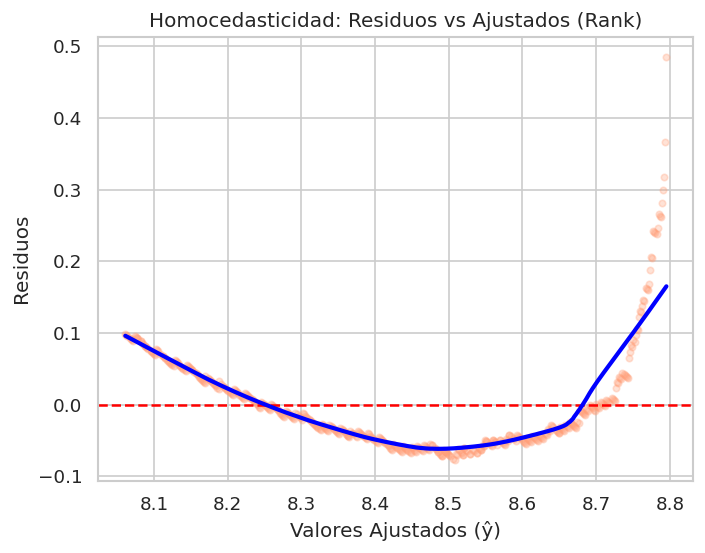

Breusch-Pagan p-value: 0.000000


In [17]:
# ================================
#   HOMOCEDASTICIDAD MODELO SIMPLE
# ================================
residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.scatter(ajustados_ols, residuos_ols, alpha=0.3, s=15, color='#ffa07a')
plt.axhline(0, color='red', linestyle='--')
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:,0], lowess[:,1], color='blue', linewidth=2.5)
plt.xlabel('Valores Ajustados (ŷ)')
plt.ylabel('Residuos')
plt.title('Homocedasticidad: Residuos vs Ajustados (Rank)')
plt.savefig('../data/graficas/homoc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)
print(f"Breusch-Pagan p-value: {lm_p:.6f}")


In [18]:

# ================================
#   OLS STATSMODELS MULTIPLE
# ================================X_ols_m = sm.add_constant(df[['rank','favorites','episodes']])
modelo_ols_multi = sm.OLS(df['score'], X_ols_m).fit()
print(modelo_ols_multi.summary())


                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     1475.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          4.64e-242
Time:                        05:46:15   Log-Likelihood:                 601.13
No. Observations:                 485   AIC:                            -1194.
Df Residuals:                     481   BIC:                            -1178.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7773      0.007   1206.496      0.0

In [19]:
# ================================
#   VIF MULTICOLINEALIDAD
# ================================
X_vif = df[['rank','favorites','episodes']]
vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)


    Variable       VIF
0       rank  1.192053
1  favorites  1.231843
2   episodes  1.362848


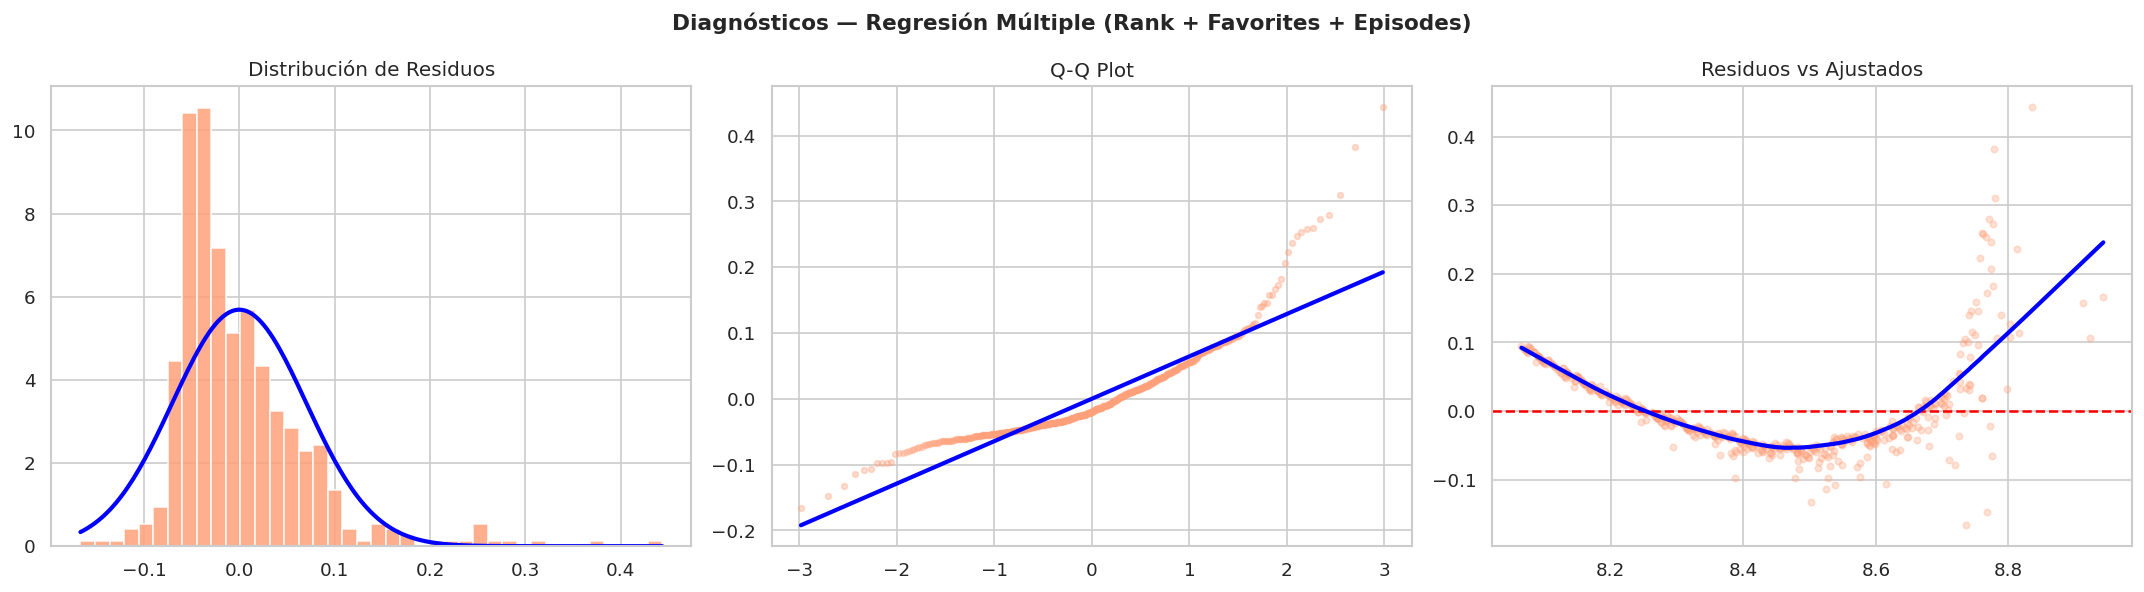

Shapiro-Wilk p-value: 0.000000
Breusch-Pagan p-value: 0.000000


In [20]:
# ================================
#   DIAGNOSTICOS COMPLETOS MULTIPLE
# ================================
residuos_m = modelo_ols_multi.resid
ajustados_m = modelo_ols_multi.fittedvalues

fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Diagnósticos — Regresión Múltiple (Rank + Favorites + Episodes)', fontsize=13, fontweight='bold')

# Histograma residuos
axes[0].hist(residuos_m, bins=40, color='#ffa07a', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()), color='blue', linewidth=2.5)
axes[0].set_title('Distribución de Residuos')

# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#ffa07a')
axes[1].plot(osm, slope*np.array(osm)+intercept, color='blue', linewidth=2.5)
axes[1].set_title('Q-Q Plot')

# Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.3, s=15, color='#ffa07a')
axes[2].axhline(0, color='red', linestyle='--')
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:,0], lowess_m[:,1], color='blue', linewidth=2.5)
axes[2].set_title('Residuos vs Ajustados')

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png', dpi=300, bbox_inches='tight')
plt.show()

# Tests
stat_sw_m, p_sw_m = stats.shapiro(residuos_m if len(residuos_m)<=5000 else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))
lm_m, lm_p_m, _, _ = het_breuschpagan(residuos_m, modelo_ols_multi.model.exog)
print(f"Shapiro-Wilk p-value: {p_sw_m:.6f}")
print(f"Breusch-Pagan p-value: {lm_p_m:.6f}")


In [21]:
# ================================
#   COMPARACION FINAL MODELOS
# ================================
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple','Regresión Múltiple'],
    'Variables': ['rank','rank + favorites + episodes'],
    'R²': [r2_score(y_test, y_pred_simple), r2_score(y_test_m, y_pred_multi)],
    'R² Aj.': [modelo_ols_simple.rsquared_adj, modelo_ols_multi.rsquared_adj],
    'RMSE': [mean_squared_error(y_test, y_pred_simple, squared=False),
             mean_squared_error(y_test_m, y_pred_multi, squared=False)],
    'MAE': [mean_absolute_error(y_test, y_pred_simple),
            mean_absolute_error(y_test_m, y_pred_multi)],
    'AIC': [modelo_ols_simple.aic, modelo_ols_multi.aic],
    'BIC': [modelo_ols_simple.bic, modelo_ols_multi.bic]
})
print(comparacion)



               Modelo                    Variables        R²    R² Aj.  \
0    Regresión Simple                         rank  0.882902  0.894690   
1  Regresión Múltiple  rank + favorites + episodes  0.890171  0.901337   

       RMSE       MAE          AIC          BIC  
0  0.083369  0.055535 -1164.626964 -1156.258666  
1  0.080740  0.054193 -1194.259299 -1177.522703  


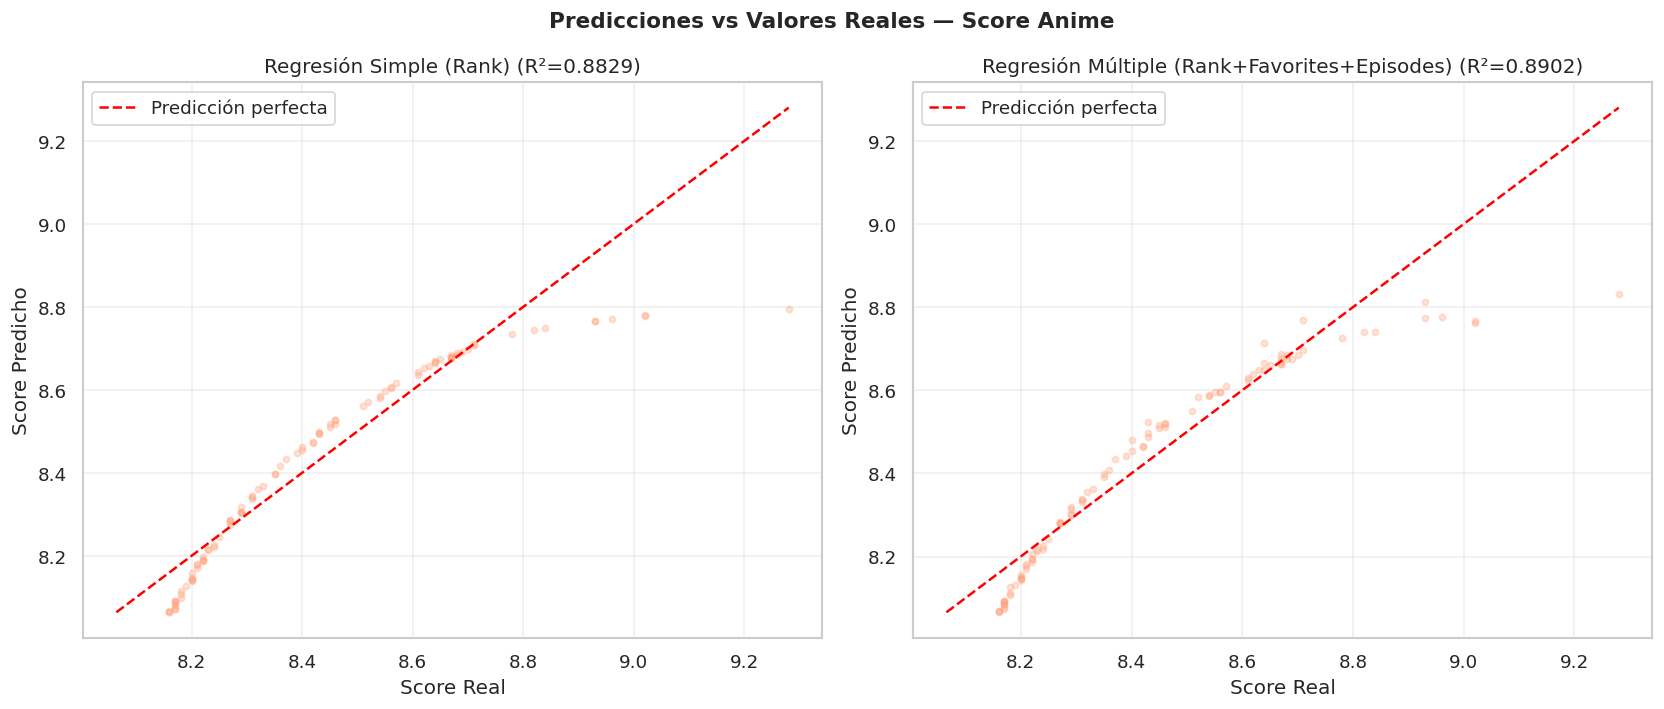

In [22]:
fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Predicciones vs Valores Reales — Score Anime', fontsize=13, fontweight='bold')

for ax,(y_real,y_pred,titulo) in zip(axes,[
    (y_test,y_pred_simple,'Regresión Simple (Rank)'),
    (y_test_m,y_pred_multi,'Regresión Múltiple (Rank+Favorites+Episodes)')
]):
    minval,maxval = min(y_real.min(),y_pred.min()), max(y_real.max(),y_pred.max())
    ax.scatter(y_real,y_pred,alpha=0.3,s=14,color='#ffa07a')
    ax.plot([minval,maxval],[minval,maxval],color='red',linestyle='--',label='Predicción perfecta')
    r2_val = r2_score(y_real,y_pred)
    ax.set_title(f'{titulo} (R²={r2_val:.4f})')
    ax.set_xlabel('Score Real')
    ax.set_ylabel('Score Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png', dpi=300, bbox_inches='tight')
plt.show()
